# Notebook 3: Treaty Structuring

Implementing and comparing Quota Share, Excess of Loss, and full reinsurance programs.

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from treaty_simulator import QuotaShare, ExcessOfLoss, ReinsuanceProgram

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

## 1. Load Portfolio

In [2]:
df = pd.read_csv('../data/processed/claims_cleaned.csv')
losses = df['loss'].values
premiums = losses / 0.70

print(f'Claims:          {len(losses):,}')
print(f'Total losses:    {losses.sum():>15,.2f}')
print(f'Total premiums:  {premiums.sum():>15,.2f}')
print(f'Loss ratio:      {losses.sum()/premiums.sum():>15.1%}')

Claims:          50,000
Total losses:     118,628,336.72
Total premiums:   169,469,052.46
Loss ratio:                70.0%


## 2. Quota Share

In [3]:
qs = QuotaShare(cession_rate=0.30, commission_rate=0.25)
qs_result = qs.apply(losses, premiums)
print(f'Ceded losses:  {qs_result["total_ceded"]:,.2f}')
print(f'Net cost:      {qs_result["net_cost"]:,.2f}')

Ceded losses:  35,588,501.02
Net cost:      38,130,536.80


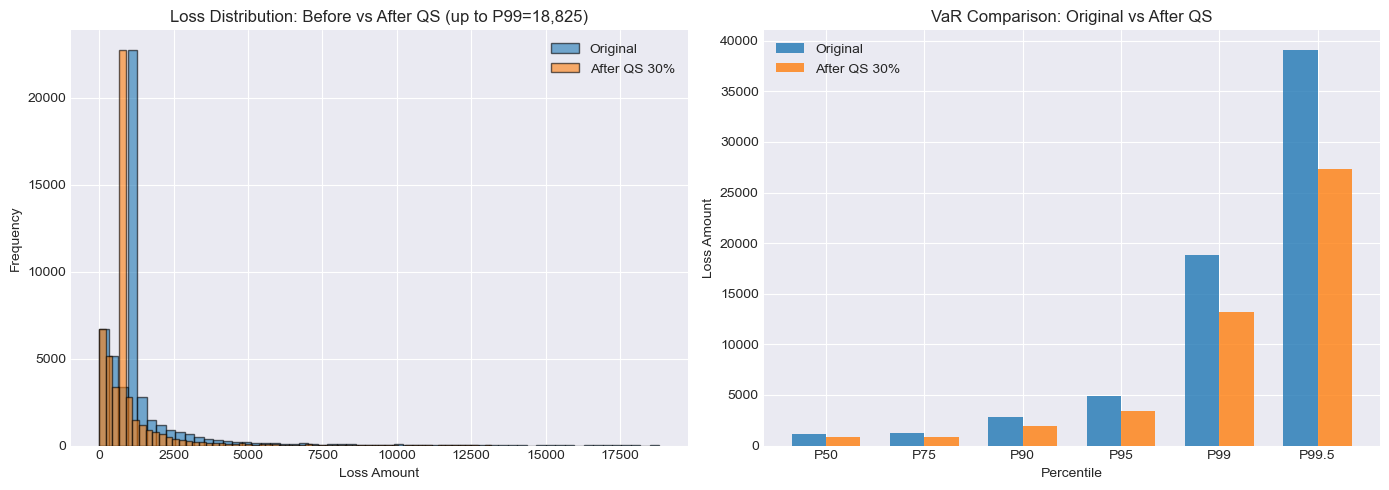

In [4]:
p99 = np.percentile(losses, 99)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bins = np.linspace(0, p99, 60)
axes[0].hist(losses[losses<=p99], bins=bins, alpha=0.6, label='Original', edgecolor='black')
axes[0].hist(qs_result['retained_losses'][qs_result['retained_losses']<=p99*0.7],
             bins=np.linspace(0, p99*0.7, 60), alpha=0.6, label='After QS 30%', edgecolor='black')
axes[0].set_xlabel('Loss Amount')
axes[0].set_ylabel('Frequency')
axes[0].set_title(f'Loss Distribution: Before vs After QS (up to P99={p99:,.0f})')
axes[0].legend()

percentiles = [50, 75, 90, 95, 99, 99.5]
orig_pct = [np.percentile(losses, p) for p in percentiles]
retn_pct = [np.percentile(qs_result['retained_losses'], p) for p in percentiles]

x = np.arange(len(percentiles))
w = 0.35
axes[1].bar(x - w/2, orig_pct, w, label='Original', alpha=0.8)
axes[1].bar(x + w/2, retn_pct, w, label='After QS 30%', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'P{p}' for p in percentiles])
axes[1].set_xlabel('Percentile')
axes[1].set_ylabel('Loss Amount')
axes[1].set_title('VaR Comparison: Original vs After QS')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/figures/09_quota_share_impact.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Excess of Loss

In [5]:
xl_structures = [
    ExcessOfLoss(retention=50_000,  limit=450_000),
    ExcessOfLoss(retention=100_000, limit=400_000),
    ExcessOfLoss(retention=150_000, limit=350_000),
    ExcessOfLoss(retention=200_000, limit=300_000),
]

records = []
for xl in xl_structures:
    r = xl.apply(losses)
    records.append({
        'structure':        xl.name,
        'retention':        xl.retention,
        'n_attaching':      r['n_attaching'],
        'total_ceded':      r['total_ceded'],
        'burning_cost':     xl.burning_cost(losses),
        'premium_15pct':    xl.premium(losses, loading=0.15),
        'var_995_retained': np.percentile(r['retained_losses'], 99.5)
    })

df_xl = pd.DataFrame(records)
print(df_xl.to_string(index=False))

      structure  retention  n_attaching  total_ceded  burning_cost  premium_15pct  var_995_retained
XL 0.5M xs 0.1M      50000          191  17747555.05   17747555.05   2.040969e+07          39071.07
XL 0.4M xs 0.1M     100000           88  11301133.11   11301133.11   1.299630e+07          39071.07
XL 0.3M xs 0.1M     150000           60   7642630.02    7642630.02   8.789025e+06          39071.07
XL 0.3M xs 0.2M     200000           40   5072159.87    5072159.87   5.832984e+06          39071.07


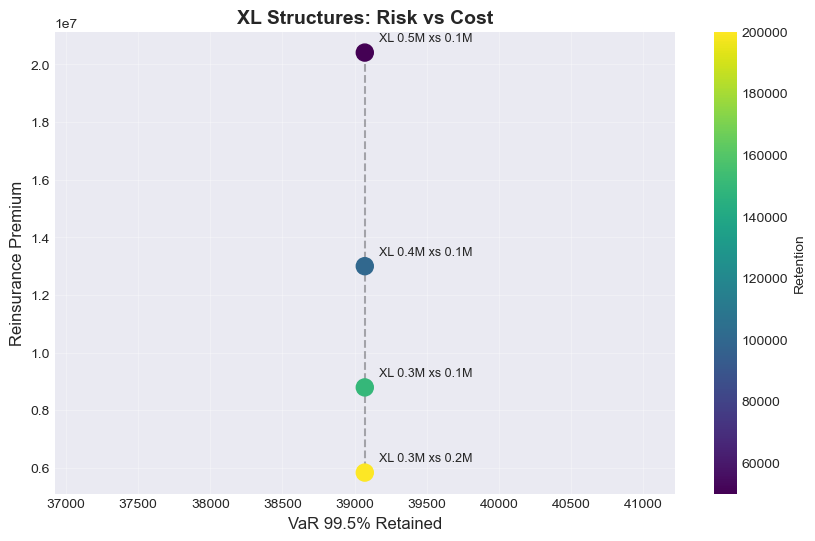

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

sc = ax.scatter(df_xl['var_995_retained'], df_xl['premium_15pct'],
                s=150, c=df_xl['retention'], cmap='viridis', zorder=5)
ax.plot(df_xl['var_995_retained'], df_xl['premium_15pct'], 'k--', alpha=0.3)

for _, row in df_xl.iterrows():
    ax.annotate(row['structure'],
                xy=(row['var_995_retained'], row['premium_15pct']),
                xytext=(10, 8), textcoords='offset points', fontsize=9)

plt.colorbar(sc, label='Retention')
ax.set_xlabel('VaR 99.5% Retained', fontsize=12)
ax.set_ylabel('Reinsurance Premium', fontsize=12)
ax.set_title('XL Structures: Risk vs Cost', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.savefig('../results/figures/10_xl_efficient_frontier.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Detailed XL Analysis

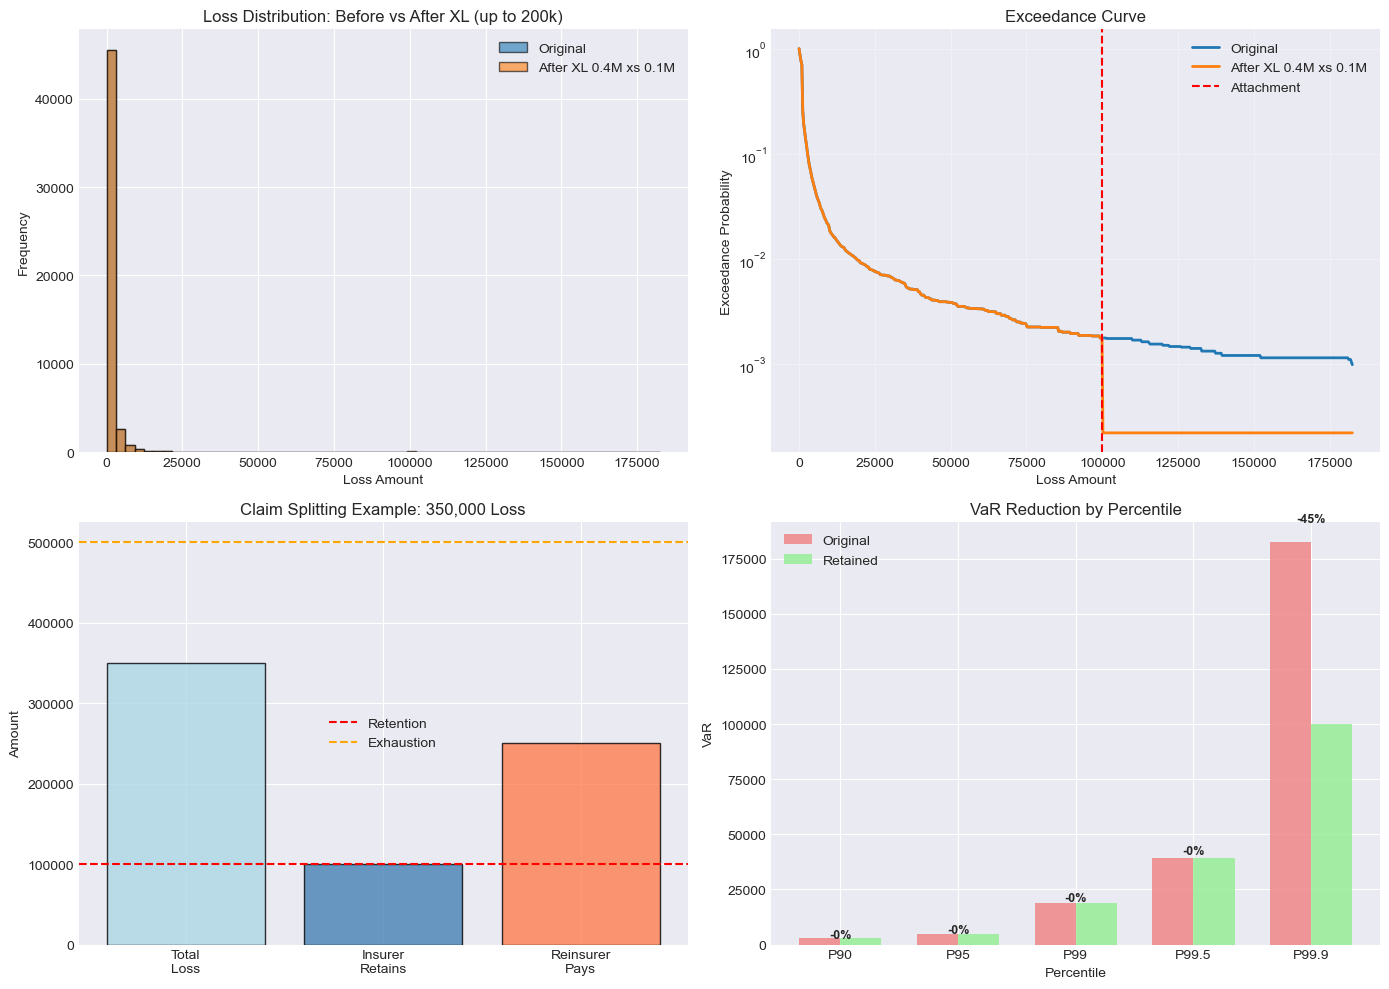

In [7]:
xl = ExcessOfLoss(retention=100_000, limit=400_000)
xl_result = xl.apply(losses)

p999 = np.percentile(losses, 99.9)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 4.1 Distribution — cap at P99.9 to show meaningful shape
bins_xl = np.linspace(0, min(p999, 200000), 60)
axes[0,0].hist(losses[losses<=200000], bins=bins_xl,
               alpha=0.6, label='Original', edgecolor='black')
axes[0,0].hist(xl_result['retained_losses'][xl_result['retained_losses']<=200000],
               bins=bins_xl, alpha=0.6, label=f'After {xl.name}', edgecolor='black')
axes[0,0].set_xlabel('Loss Amount')
axes[0,0].set_ylabel('Frequency')
axes[0,0].set_title('Loss Distribution: Before vs After XL (up to 200k)')
axes[0,0].legend()

# 4.2 Exceedance curve
thresh_range = np.linspace(0, p999, 600)
exc_orig = np.array([np.mean(losses > t) for t in thresh_range])
exc_retn = np.array([np.mean(xl_result['retained_losses'] > t) for t in thresh_range])

axes[0,1].plot(thresh_range, exc_orig, label='Original', linewidth=2)
axes[0,1].plot(thresh_range, exc_retn, label=f'After {xl.name}', linewidth=2)
axes[0,1].axvline(x=xl.retention, color='red', linestyle='--', label='Attachment')
axes[0,1].set_xlabel('Loss Amount')
axes[0,1].set_ylabel('Exceedance Probability')
axes[0,1].set_title('Exceedance Curve')
axes[0,1].set_yscale('log')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# 4.3 Claim splitting example
sample_loss  = 350_000
ceded_sample = np.clip(sample_loss - xl.retention, 0, xl.limit)
retained_sample = sample_loss - ceded_sample

categories = ['Total\nLoss', 'Insurer\nRetains', 'Reinsurer\nPays']
values     = [sample_loss, retained_sample, ceded_sample]
colors     = ['lightblue', 'steelblue', 'coral']

axes[1,0].bar(categories, values, color=colors, edgecolor='black', alpha=0.8)
axes[1,0].set_ylabel('Amount')
axes[1,0].set_title(f'Claim Splitting Example: {sample_loss:,} Loss')
axes[1,0].axhline(y=xl.retention,  color='red',    linestyle='--', label='Retention')
axes[1,0].axhline(y=xl.exhaustion, color='orange', linestyle='--', label='Exhaustion')
axes[1,0].legend()

# 4.4 VaR reduction
percentiles = [90, 95, 99, 99.5, 99.9]
var_orig = [np.percentile(losses, p) for p in percentiles]
var_retn = [np.percentile(xl_result['retained_losses'], p) for p in percentiles]
reductions = [(o-r)/o*100 for o, r in zip(var_orig, var_retn)]

x4 = np.arange(len(percentiles))
w4 = 0.35
axes[1,1].bar(x4 - w4/2, var_orig, w4, label='Original', alpha=0.8, color='lightcoral')
axes[1,1].bar(x4 + w4/2, var_retn, w4, label='Retained', alpha=0.8, color='lightgreen')

for i, red in enumerate(reductions):
    axes[1,1].text(i, max(var_orig[i], var_retn[i]) * 1.05,
                   f'-{red:.0f}%', ha='center', fontsize=9, fontweight='bold')

axes[1,1].set_xticks(x4)
axes[1,1].set_xticklabels([f'P{p}' for p in percentiles])
axes[1,1].set_xlabel('Percentile')
axes[1,1].set_ylabel('VaR')
axes[1,1].set_title('VaR Reduction by Percentile')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('../results/figures/11_xl_detailed.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Full Reinsurance Program

In [8]:
program = ReinsuanceProgram('Comprehensive P&C Program')
program.add_treaty(QuotaShare(cession_rate=0.20, commission_rate=0.25))
program.add_treaty(ExcessOfLoss(retention=100_000, limit=400_000))
program.add_treaty(ExcessOfLoss(retention=500_000, limit=500_000))

results = program.summary(losses)

summary = {
    'metric': ['Original Losses', 'Retained Losses', 'Ceded Losses', 'Cession Rate',
               'VaR 95 Original', 'VaR 95 Retained',
               'VaR 995 Original', 'VaR 995 Retained'],
    'value': [
        results['original_total'], results['final_retained_total'],
        results['total_ceded'],    results['cession_rate'],
        np.percentile(losses, 95),
        np.percentile(results['final_retained'], 95),
        np.percentile(losses, 99.5),
        np.percentile(results['final_retained'], 99.5)
    ]
}
pd.DataFrame(summary).to_csv('../results/tables/program_summary.csv', index=False)
print('Summary saved.')

  COMPREHENSIVE P&C PROGRAM

FINANCIAL SUMMARY
  Original losses:         118,628,336.72
  Retained losses:          84,439,745.74
  Ceded losses:             34,188,590.98
  Cession rate:                     28.8%

TREATIES IN PROGRAM (3):
  1. Quota Share 20%
     Ceded: 23,725,667.34
  2. XL 0.4M xs 0.1M
     Ceded: 8,509,387.64
  3. XL 0.5M xs 0.5M
     Ceded: 1,953,536.00
Summary saved.
